# FABN Portfolio Optimizer — Surplus-CVaR + Duration Match  *(Phase 1, single-period)*

This notebook is a variant of `FABN_Optimizer_SAP_Shadow_SWAP.ipynb`. It changes **two** things and keeps everything else (objective, budget, turnover, facility, issuer caps, swap overlay) identical:

| | `..._Shadow_SWAP` (current) | **This notebook** |
|---|---|---|
| **Risk measure** | CVaR on **asset** forced-sale loss `1 − MV/BV` | CVaR on **surplus** = assets **net of the FABN liability** |
| **Duration control** | band relaxed to inert (`eps_D_eff = 100`) | **hard match**: `D(bonds) + D(swap) = D_FABN` (exact) |

**Why.** The asset-only CVaR treats *all* duration as downside, so it fights ALM matching — matching the liability is infeasible under a tight tail budget, and the pay-fixed swap only ever pushes effective duration *below* the note. Netting the liability's own rate move (`1 − MV/BV` on assets **minus** the liability's MV decline) makes a **duration-matched book rate-immune**: the rate tail cancels and only the credit/spread tail remains. Then the hard match makes the swap do its intended job — hold the best bonds wherever they sit on the curve and size the swap so **assets + swap duration = liability duration**.

$$\text{surplus loss}_s=\underbrace{\sum_i \text{relloss}_{s,i}\,h_i+\sum_k D^{sw}_k\,\Delta r_s\,v_k}_{\text{asset+swap MV decline}}-\underbrace{\big(BV_L-MV_L(\Delta r_s)\big)}_{\text{liability MV decline (rate-only)}}$$

**Run order:** `Date Selection → 0 → 1A → 1B → 1C → 2 → 3 → 3C → 4 → 5 → 6 → 7`


---
## Section 0 — Pipeline Run & Imports

In [1]:
# =============================================================================
# DATE SELECTION  --  change this date, then re-run all cells top-to-bottom
# =============================================================================
# This is the SINGLE source of truth for the date. The pipeline is run in-memory
# below at exactly this date (Section 0), so you do NOT need to also edit the
# pipeline notebook. (The shared pipeline file is never modified.)
# =============================================================================
import pandas as pd

optimization_date = pd.Timestamp("2025-01-15")   # <- CHANGE THIS DATE

_FABN_ISSUE    = pd.Timestamp("2022-09-06")
_FABN_MATURITY = pd.Timestamp("2027-09-06")
assert optimization_date <= pd.Timestamp.today(), "Date is in the future -- no market data."
assert optimization_date > _FABN_ISSUE,  f"Date must be after FABN issue ({_FABN_ISSUE.date()})."
assert optimization_date < _FABN_MATURITY, f"Date must be before FABN maturity ({_FABN_MATURITY.date()})."
print(f"Optimization date selected : {optimization_date.date()}")

Optimization date selected : 2025-01-15


In [2]:
# Run the shared data pipeline (bond universe, cashflows, durations, C-1, spreads,
# prices, book yields, tau, CVaR scenarios) -> `pipeline`.
#
# We exec it IN-MEMORY at `optimization_date` instead of `%run`, because the pipeline
# hardcodes its own date and `%run` would override the selection above. This reads the
# shared pipeline notebook but never writes to it; the only change is pinning the date.
import json as _json
_PIPE = "FABN_Data_Pipeline_SAP_SWAP.ipynb"
_src = []
for _c in _json.load(open(_PIPE))["cells"]:
    if _c["cell_type"] == "code":
        _s = "".join(_c["source"]).replace('pd.Timestamp("2024-03-29")',
                                           f'pd.Timestamp("{optimization_date.date()}")')
        _src.append(_s)
exec(compile("\n\n".join(_src), _PIPE, "exec"), globals())   # populates `pipeline`, FABN_MATURITY, ...

import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import fabn_finance_SWAP as ff
print(f"\nPipeline ready for {optimization_date.date()}  |  D_FABN = {pipeline['D_FABN']:.4f} yr")

Connected: insurance-backed-securities
Optimization date  : 2025-01-15
FABN issue/maturity: 2022-09-06 → 2027-09-06
Budget H           : $500,000,000
r_FABN             : 3.205%


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Universe size N = 303 bonds


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Spread coverage : 301/303 bonds  (2 missing)
Spread range    : -1.6 – 153.7 bps


...

CVaR shock history: 375 days DGS5+IG-OAS (FRED, attempt 1)


CVaR scenarios: S=250 | rate shock std 31bp | spread shock std 7bp
Portfolio-avg loss: worst-5% mean ~ +1.50% of book | median -0.03%


,Metric,Value,Notes
0,Universe size (N),303,
1,Payment dates (T),850,
2,Quarterly periods (Q),33,
3,Spread mean (bps),59.4,
4,Book yield mean (%),5.44,
5,Bid-ask tau mean (bps),5.9,
6,Duration mean (yrs),2.97,
7,C1 charge mean (%),0.911,
8,FABN D target (yrs),2.489641,
9,Budget H ($M),500.0,



pipeline dict ready.



Pipeline ready for 2025-01-15  |  D_FABN = 2.4896 yr


---
## Section 1 — Data & Parameters

In [3]:
# =============================================================================
# 1A. UNPACK PIPELINE  --  always run
# =============================================================================
N           = pipeline["N"]
CUSIPS      = pipeline["CUSIPS"]
book_yield  = pipeline["book_yield"]
coupon_inc  = pipeline["coupon_inc"]
amort_inc   = pipeline["amort_inc"]
spread      = pipeline["spread"]
durs        = pipeline["durs"]
theta       = pipeline["theta"]
tau         = pipeline["tau"]
price       = pipeline["price"]
h_curr      = pipeline["h_curr"]

qtr_bond_cf = pipeline["qtr_bond_cf"]
qtr_fabn_cf = pipeline["qtr_fabn_cf"]
qtr_idx     = pipeline["qtr_idx"]

# Truncate quarterly grid to FABN maturity horizon
_fabn_qtr   = pd.Period(_FABN_MATURITY, freq="Q")
_keep       = qtr_idx <= _fabn_qtr
qtr_bond_cf = qtr_bond_cf[_keep]
qtr_fabn_cf = qtr_fabn_cf[_keep]
qtr_idx     = qtr_idx[_keep]
Q           = len(qtr_idx)

H            = pipeline["H"]
r_FABN       = pipeline["r_FABN"]
D_FABN       = pipeline["D_FABN"]
RBC_bar      = pipeline["RBC_bar"]
cvar_relloss = pipeline["cvar_relloss"]   # (S,N) per-$ asset forced-sale loss
cvar_d_rate  = np.asarray(pipeline["cvar_d_rate"])   # (S,) per-scenario RATE shock
cvar_alpha   = pipeline["cvar_alpha"]     # tail level (worst 5%)

print(f"Pipeline loaded: N={N}, Q={Q} (to {qtr_idx[-1]})  |  date {optimization_date.date()}")
print(f"D_FABN = {D_FABN:.4f} yr  |  book yield mean {book_yield.mean()*100:.2f}%  |  scenarios S={cvar_relloss.shape[0]}")

Pipeline loaded: N=303, Q=11 (to 2027Q3)  |  date 2025-01-15
D_FABN = 2.4896 yr  |  book yield mean 5.44%  |  scenarios S=250


In [4]:
# =============================================================================
# 1B. OBJECTIVE PARAMETERS + SWAP OVERLAY  --  tune here
# =============================================================================
cost_of_capital = 0.15
lambda_cap      = cost_of_capital * RBC_bar     # lambda in the SAP objective
r_save          = 0.0                           # facility surplus earns 0 (no free parking)
dt_q            = 0.25
delta           = 0.05                          # issuer concentration cap (5% of H)

# -- Surplus CVaR tail-loss control (replaces the asset-only CVaR) -------------
use_surplus_cvar = True     # True: net the FABN liability into the tail loss
phi_cvar         = 0.01     # CVaR limit: worst-(1-alpha) surplus tail loss <= phi_cvar * H

# -- Income basis -------------------------------------------------------------
income_basis = "net"        # NII_i = (book_yield_i - r_FABN) * h_i
nii_rate = (book_yield - r_FABN) if income_basis == "net" else book_yield.copy()

# -- Interest rate swap overlay (pay-fixed, at-the-money = pure rate hedge) ----
use_swaps       = True
swap_maturities = [1.0, 2.0, 3.0]               # pay-fixed swap tenors (years)
r_float         = 0.0435                        # SOFR proxy on optimization_date
swap_rates_k    = [r_float] * len(swap_maturities)   # at-the-money: zero carry
mu_swap         = 0.002                          # C-3 RBC charge on swap notional
swap_cap_pct    = 0.20                           # max total swap notional as % of H
K               = len(swap_maturities) if use_swaps else 0

if use_swaps and K > 0:
    D_swap  = -np.array([ff.swap_fixed_leg_duration(m, c, r_float, settlement_freq=2)
                         for m, c in zip(swap_maturities, swap_rates_k)])   # pay-fixed: negative duration
    cf_swap = np.array([ff.swap_quarterly_cashflows(c, r_float, m, Q, settlement_freq=2)
                        for m, c in zip(swap_maturities, swap_rates_k)])
else:
    K = 0; D_swap = np.array([]); cf_swap = np.empty((0, Q))

print(f"lambda_cap = {lambda_cap:.4f}   |   phi_cvar = {phi_cvar:.2%}  (surplus)  |  swaps K={K}, cap {swap_cap_pct:.0%}xH")
print(f"Swap durations (pay-fixed): {np.round(D_swap,4)}  ->  max offsetable duration at cap "
      f"~ {abs(D_swap.min())*swap_cap_pct if K else 0:.3f} yr")

lambda_cap = 0.4500   |   phi_cvar = 1.00%  (surplus)  |  swaps K=3, cap 20%xH
Swap durations (pay-fixed): [-0.9481 -1.8563 -2.7263]  ->  max offsetable duration at cap ~ 0.545 yr


### 1C — Liability MV decline under rate shocks  *(the surplus-CVaR input)*

The FABN is a fixed obligation discounted at `r_FABN`; it carries **no credit spread**, so it reprices under the **rate** shock only. `cvar_liab_decline[s] = BV_L − MV_L(Δrate_s)` is the dollar decline in the liability's market value in scenario `s` (positive when rates rise). Subtracting it from the asset+swap decline turns the tail measure from *asset liquidation risk* into *surplus (ALM) risk*.

In [5]:
# =============================================================================
# 1C. LIABILITY MV DECLINE  --  rate-only reprice of the FABN cashflows
# =============================================================================
t_quarters = np.array([dt_q * (q + 1) for q in range(Q)])
_liab_cf   = qtr_fabn_cf.reshape(Q, 1).astype(float)          # ($) per quarter, one "instrument"

BV_L = ff.market_values_under_shocks(_liab_cf, t_quarters, np.array([r_FABN]),
                                     np.array([0.0]), np.array([0.0]))[0, 0]
MV_L = ff.market_values_under_shocks(_liab_cf, t_quarters, np.array([r_FABN]),
                                     cvar_d_rate, np.zeros_like(cvar_d_rate))[:, 0]
cvar_liab_decline = BV_L - MV_L                               # (S,) $ decline, >0 when rates rise

_impliedD = cvar_liab_decline.max() / (cvar_d_rate.max() * BV_L) if cvar_d_rate.max() > 0 else np.nan
print(f"Liability BV_L = ${BV_L:,.0f}   (D_FABN = {D_FABN:.3f} yr, implied from shocks ~ {_impliedD:.2f} yr)")
print(f"Liability MV decline over {len(cvar_liab_decline)} scenarios: "
      f"mean ${cvar_liab_decline.mean():,.0f} | worst ${cvar_liab_decline.max():,.0f}")

Liability BV_L = $504,320,737   (D_FABN = 2.490 yr, implied from shocks ~ 2.52 yr)
Liability MV decline over 250 scenarios: mean $187,716 | worst $8,144,442


---
## Section 2 — Gurobi Model (surplus CVaR + hard duration match)

One reusable solver `solve_model(...)` builds the LP so the base case, the φ-sweep (§5) and the swap-capacity demo (§6) all share identical logic. The only structural differences vs the asset-CVaR notebook are the **duration equality** and the **liability-netted CVaR loss** (both flagged inline).

In [6]:
# =============================================================================
# 2. SOLVER  --  surplus-CVaR + hard duration match (reused everywhere)
# =============================================================================
S_scen = cvar_relloss.shape[0]
n_tail = int(np.ceil((1.0 - cvar_alpha) * S_scen))
issuer_groups = {}
for _i, _c in enumerate(CUSIPS):
    issuer_groups.setdefault(_c[:6], []).append(_i)

def solve_model(phi_cvar=phi_cvar, use_swaps=use_swaps, dur_match=True,
                surplus=True, elig=None, swap_tenors=None, swap_cap=swap_cap_pct,
                verbose=False):
    """Single-period SAP optimizer.
      surplus=True  -> CVaR on assets NET of the FABN liability
      dur_match=True-> hard constraint  D(bonds)+D(swap) == D_FABN  (exact match)
      elig          -> boolean mask of investable bonds (None = all)
      swap_tenors   -> override swap menu (None = the 1B menu)
    """
    if elig is None:
        elig = np.ones(N, dtype=bool)
    # swap menu (allow the demo to pass longer tenors)
    if swap_tenors is None:
        _mat, _Dsw, _cfsw, _Ksw = swap_maturities, D_swap, cf_swap, K
    else:
        _mat  = swap_tenors
        _srk  = [r_float] * len(_mat)
        _Dsw  = -np.array([ff.swap_fixed_leg_duration(m, c, r_float, settlement_freq=2) for m, c in zip(_mat, _srk)])
        _cfsw = np.array([ff.swap_quarterly_cashflows(c, r_float, m, Q, settlement_freq=2) for m, c in zip(_mat, _srk)])
        _Ksw  = len(_mat)
    hasK = use_swaps and _Ksw > 0

    m = gp.Model("FABN_Surplus_CVaR"); m.Params.OutputFlag = 1 if verbose else 0
    h  = m.addVars(N, lb=0.0, name="h")
    tp = m.addVars(N, lb=0.0, name="tc_plus"); tm = m.addVars(N, lb=0.0, name="tc_minus")
    B  = m.addVars(Q, lb=0.0, name="B");       sn = m.addVars(Q, lb=0.0, name="s_net")
    v  = m.addVars(_Ksw, lb=0.0, name="v") if hasK else {}
    for i in range(N):
        if not elig[i]:
            h[i].ub = 0.0

    # -- Objective: statutory NII - lambda*RBC - turnover - swap capital -------
    NII  = gp.quicksum(nii_rate[i] * h[i] for i in range(N))
    RBC  = gp.quicksum(theta[i]    * h[i] for i in range(N))
    TXN  = gp.quicksum(tau[i] * (tp[i] + tm[i]) for i in range(N))
    SCAP = lambda_cap * mu_swap * gp.quicksum(v[k] for k in range(_Ksw)) if hasK else 0.0
    m.setObjective(NII - lambda_cap * RBC - TXN - SCAP, GRB.MAXIMIZE)

    # -- Budget ----------------------------------------------------------------
    m.addConstr(gp.quicksum(h[i] for i in range(N)) == H, name="budget")

    # -- HARD DURATION MATCH:  D(bonds) + D(swap) == D_FABN  (per instruction) --
    dur_bonds = gp.quicksum(durs[i] * h[i] for i in range(N))
    dur_swaps = gp.quicksum(float(_Dsw[k]) * v[k] for k in range(_Ksw)) if hasK else 0.0
    if dur_match:
        m.addConstr(dur_bonds + dur_swaps == D_FABN * H, name="dur_match")
    # (if dur_match=False the duration is left free -- for diagnostics only)

    # -- Turnover decomposition ------------------------------------------------
    for i in range(N):
        m.addConstr(h[i] - h_curr[i] == tp[i] - tm[i], name=f"tc_{i}")

    # -- Lending-facility balance (buffer; r_save=0) ---------------------------
    for q in range(Q):
        CF_A  = gp.quicksum(qtr_bond_cf[q, i] * h[i] for i in range(N))
        CF_sw = gp.quicksum(float(_cfsw[k, q]) * v[k] for k in range(_Ksw)) if hasK else 0.0
        CF_L  = float(qtr_fabn_cf[q])
        if q == 0:
            m.addConstr(B[q] - sn[q] == CF_A + CF_sw - CF_L, name=f"fac_{q}")
        else:
            m.addConstr(B[q] - sn[q] == (1.0 + r_save*dt_q)*B[q-1] + CF_A + CF_sw - CF_L, name=f"fac_{q}")

    # -- Swap notional cap + issuer concentration ------------------------------
    if hasK:
        m.addConstr(gp.quicksum(v[k] for k in range(_Ksw)) <= swap_cap * H, name="swap_cap")
    for iss, bidx in issuer_groups.items():
        m.addConstr(gp.quicksum(h[i] for i in bidx) <= delta * H, name=f"conc_{iss}")

    # -- SURPLUS CVaR (Rockafellar-Uryasev, linear) ----------------------------
    zeta = m.addVar(lb=-GRB.INFINITY, name="cvar_zeta")
    z    = m.addVars(S_scen, lb=0.0, name="cvar_z")
    for s in range(S_scen):
        asset_loss = gp.quicksum(float(cvar_relloss[s, i]) * h[i] for i in range(N))
        if hasK:                                          # swap MV change (rate only)
            asset_loss = asset_loss + gp.quicksum(float(_Dsw[k]) * float(cvar_d_rate[s]) * v[k] for k in range(_Ksw))
        loss_s = asset_loss - (float(cvar_liab_decline[s]) if surplus else 0.0)   # <-- net the liability
        m.addConstr(z[s] >= loss_s - zeta, name=f"cvar_{s}")
    cvar_expr = zeta + (1.0 / ((1.0 - cvar_alpha) * S_scen)) * gp.quicksum(z[s] for s in range(S_scen))
    m.addConstr(cvar_expr <= phi_cvar * H, name="cvar_limit")

    m.optimize()
    if m.Status != GRB.OPTIMAL:
        return {"status": m.Status, "ok": False}

    ho = np.array([h[i].X for i in range(N)])
    vo = np.array([v[k].X for k in range(_Ksw)]) if hasK else np.zeros(0)
    # realized honest tail losses (asset vs surplus) for the same book
    a_loss = cvar_relloss @ ho + (cvar_d_rate[:, None] * (_Dsw * vo)[None, :]).sum(axis=1) if hasK else cvar_relloss @ ho
    s_loss = a_loss - cvar_liab_decline
    sel = ho > 1.0
    w   = ho[sel] / ho[sel].sum() if sel.any() else np.zeros(0)
    return dict(ok=True, model=m, h=ho, v=vo, Dsw=_Dsw, mat=_mat, sel=sel,
        D_bonds=float((durs*ho).sum())/H, D_swap=float((_Dsw*vo).sum())/H if hasK else 0.0,
        D_eff=(float((durs*ho).sum()) + (float((_Dsw*vo).sum()) if hasK else 0.0))/H,
        swap_notional=float(vo.sum()),
        NII=float((nii_rate*ho).sum()), coupon=float((coupon_inc*ho).sum()), amort=float((amort_inc*ho).sum()),
        RBC=float((theta*ho).sum()), turnover=float((tau*(np.array([tp[i].X for i in range(N)])+np.array([tm[i].X for i in range(N)]))).sum()),
        swap_cap_cost=lambda_cap*mu_swap*float(vo.sum()), SAP=m.ObjVal,
        asset_tail=float(np.sort(a_loss)[-n_tail:].mean()), surplus_tail=float(np.sort(s_loss)[-n_tail:].mean()),
        nsel=int(sel.sum()),
        w_yield=float((book_yield[sel]*w).sum()) if sel.any() else 0.0,
        w_spread=float((spread[sel]*w).sum()) if sel.any() else 0.0,
        w_dur=float((durs[sel]*w).sum()) if sel.any() else 0.0,
        w_theta=float((theta[sel]*w).sum()) if sel.any() else 0.0)

res = solve_model(phi_cvar=phi_cvar, verbose=True)
print("\\nStatus OK" if res["ok"] else f"\\nStatus {res['status']} (not optimal)")

Restricted license - for non-production use only - expires 2027-11-29


Set parameter OutputFlag to value 1


Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 25.5.0 25F71)


CPU model: Apple M4 Pro


...

Iteration    Objective       Primal Inf.    Dual Inf.      Time


     315    1.2477660e+07   0.000000e+00   0.000000e+00      0s


Solved in 315 iterations and 0.02 seconds (0.04 work units)


Optimal objective  1.247766014e+07


\nStatus OK


---
## Section 3 — Results

In [7]:
# =============================================================================
# 3. RESULTS  --  objective decomposition, duration match, surplus vs asset tail
# =============================================================================
assert res["ok"], "Model not optimal -- inspect Section 2."
r = res
req_cap = RBC_bar * r["RBC"]
earn_per_cap = r["NII"] / req_cap if req_cap > 0 else float("nan")

print("="*64)
print(f"  SAP OBJECTIVE              : ${r['SAP']:>15,.2f}")
print(f"  (1) Statutory NII          : ${r['NII']:>15,.2f}")
print(f"      - coupon income        : ${r['coupon']:>15,.2f}")
print(f"      - amortization         : ${r['amort']:>15,.2f}")
print(f"  (2) Capital cost lambda*RBC: ${lambda_cap*r['RBC']:>15,.2f}")
print(f"  (3) Turnover cost          : ${r['turnover']:>15,.2f}")
print(f"  (4) Swap capital cost      : ${r['swap_cap_cost']:>15,.2f}")
print("-"*64)
print(f"  Statutory earnings / req. capital : {earn_per_cap:.4f}")
print("="*64)
print(f"  Duration  bonds {r['D_bonds']:.4f} + swap {r['D_swap']:+.4f} = EFFECTIVE {r['D_eff']:.4f} yr")
print(f"            target D_FABN = {D_FABN:.4f} yr   ->  match error {r['D_eff']-D_FABN:+.2e} yr")
print(f"  Swap notional : ${r['swap_notional']:,.0f}  ({r['swap_notional']/H:.1%} of H)")
print("-"*64)
print(f"  Worst-{1-cvar_alpha:.0%} tail loss   ASSET-only  : ${r['asset_tail']:>13,.0f}")
print(f"  Worst-{1-cvar_alpha:.0%} tail loss   SURPLUS     : ${r['surplus_tail']:>13,.0f}   <= budget ${phi_cvar*H:,.0f}")
print(f"  -> netting the liability removes ${r['asset_tail']-r['surplus_tail']:,.0f} of RATE tail; "
      f"residual is credit/spread.")
print("="*64)

# -- Constraint status table ---------------------------------------------------
import pandas as pd
rows = [
    ("Budget (Sum h = H)",                 r["h"].sum(),      H,             abs(r["h"].sum()-H) < 1.0),
    ("Duration match (D_eff = D_FABN)",    r["D_eff"],        D_FABN,        abs(r["D_eff"]-D_FABN) < 1e-4),
    (f"Surplus CVaR (<= phi*H)",           r["surplus_tail"], phi_cvar*H,    r["surplus_tail"] <= phi_cvar*H + 1.0),
    ("Swap notional (<= cap)",             r["swap_notional"],swap_cap_pct*H,r["swap_notional"] <= swap_cap_pct*H + 1.0),
]
display(pd.DataFrame({"Constraint":[x[0] for x in rows], "Value":[x[1] for x in rows],
                      "Bound":[x[2] for x in rows], "Pass":["PASS" if x[3] else "FAIL" for x in rows]}))

# -- Swap overlay report -------------------------------------------------------
if r["swap_notional"] > 1.0:
    sw = pd.DataFrame([{
        "Tenor": f"{r['mat'][k]:.0f}yr", "Notional ($M)": f"{r['v'][k]/1e6:.2f}",
        "Dur contrib (yr)": f"{r['Dsw'][k]*r['v'][k]/H:+.4f}",
    } for k in range(len(r["mat"]))])
    print("\\nSWAP OVERLAY"); display(sw)
    print(f"Total swap: ${r['swap_notional']/1e6:.1f}M  ->  duration contribution {r['D_swap']:+.4f} yr")
else:
    print("\\nSwap overlay allocated ~$0: the credit-optimal bond book already matches D_FABN,")
    print("so no duration correction is needed. (See Section 6 for when the swap DOES activate.)")

  SAP OBJECTIVE              : $  12,477,660.14
  (1) Statutory NII          : $  15,479,564.72
      - coupon income        : $  29,268,640.38
      - amortization         : $   2,235,924.34
  (2) Capital cost lambda*RBC: $   2,450,438.29
  (3) Turnover cost          : $     551,466.29
  (4) Swap capital cost      : $           0.00
----------------------------------------------------------------
  Statutory earnings / req. capital : 0.9476
  Duration  bonds 2.4896 + swap +0.0000 = EFFECTIVE 2.4896 yr
            target D_FABN = 2.4896 yr   ->  match error -8.88e-16 yr
  Swap notional : $0  (0.0% of H)
----------------------------------------------------------------
  Worst-5% tail loss   ASSET-only  : $    6,210,498
  Worst-5% tail loss   SURPLUS     : $    1,630,097   <= budget $5,000,000
  -> netting the liability removes $4,580,401 of RATE tail; residual is credit/spread.


,Constraint,Value,Bound,Pass
0,Budget (Sum h = H),5.000000e+08,5.000000e+08,PASS
1,Duration match (D_eff = D_FABN),2.489641e+00,2.489641e+00,PASS
2,Surplus CVaR (<= phi*H),1.630097e+06,5.000000e+06,PASS
3,Swap notional (<= cap),0.000000e+00,1.000000e+08,PASS


\nSwap overlay allocated ~$0: the credit-optimal bond book already matches D_FABN,
so no duration correction is needed. (See Section 6 for when the swap DOES activate.)


---
## Section 3C — Duration attribution & the surplus netting

Two pictures: (left) the swap sizes so **bonds + swap = the liability duration exactly**; (right) netting the liability collapses the **rate** tail, leaving only the credit/spread tail that the surplus-CVaR actually governs.

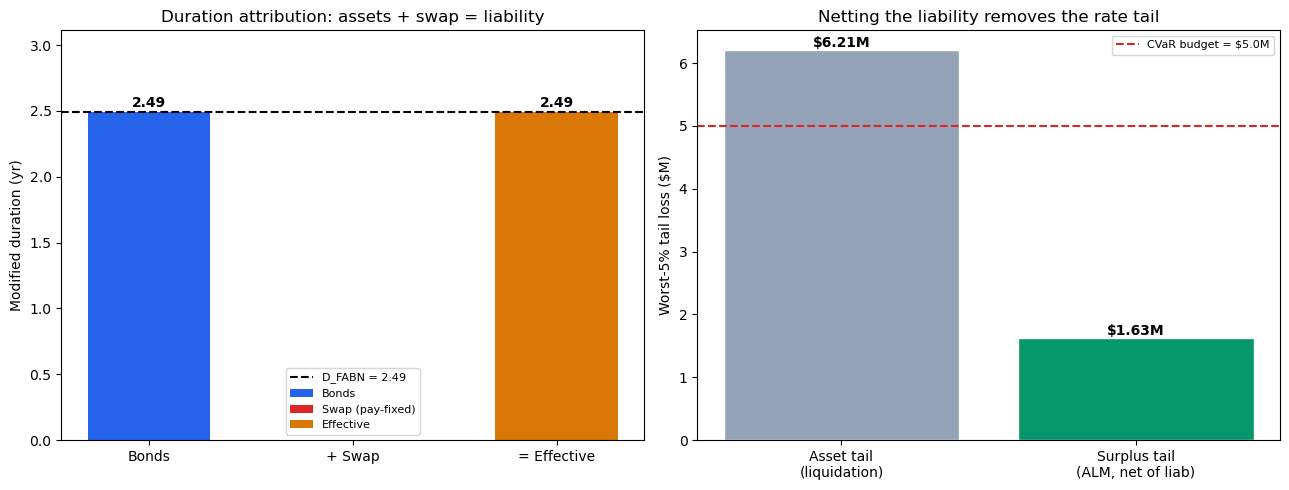

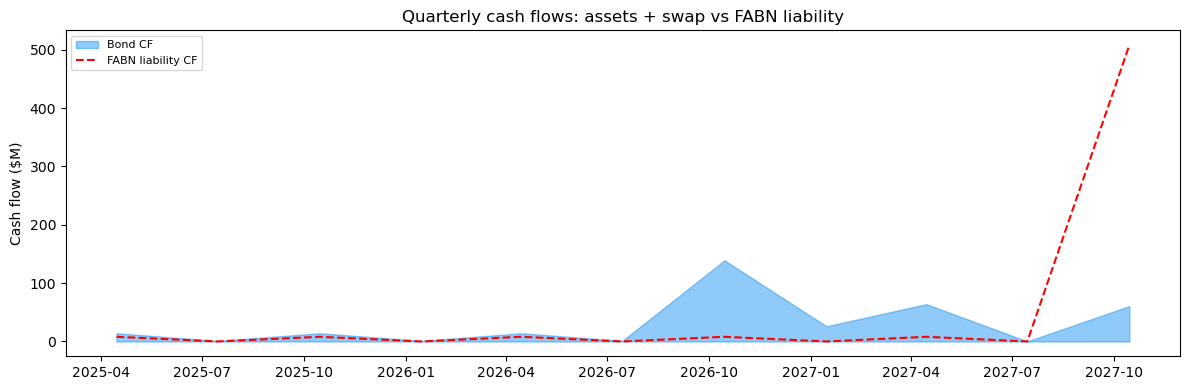

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# 3C-1: duration attribution
b, s2, e = r["D_bonds"], r["D_swap"], r["D_eff"]
ax[0].bar(0, b, 0.6, color="#2563eb", label="Bonds")
ax[0].bar(1, s2, 0.6, bottom=b, color="#dc2626", label="Swap (pay-fixed)")
ax[0].bar(2, e, 0.6, color="#d97706", label="Effective")
ax[0].axhline(D_FABN, color="black", ls="--", lw=1.5, label=f"D_FABN = {D_FABN:.2f}")
for x, val in [(0, b), (2, e)]:
    ax[0].text(x, val+0.04, f"{val:.2f}", ha="center", fontweight="bold")
ax[0].set_xticks([0,1,2]); ax[0].set_xticklabels(["Bonds","+ Swap","= Effective"])
ax[0].set_ylabel("Modified duration (yr)"); ax[0].set_ylim(0, max(b, e, D_FABN)*1.25)
ax[0].set_title("Duration attribution: assets + swap = liability"); ax[0].legend(fontsize=8)

# 3C-2: asset vs surplus tail
ax[1].bar(["Asset tail\n(liquidation)", "Surplus tail\n(ALM, net of liab)"],
          [r["asset_tail"]/1e6, r["surplus_tail"]/1e6], color=["#94a3b8","#059669"],
          edgecolor="white")
ax[1].axhline(phi_cvar*H/1e6, color="#dc2626", ls="--", lw=1.5, label=f"CVaR budget = ${phi_cvar*H/1e6:.1f}M")
for i, val in enumerate([r["asset_tail"]/1e6, r["surplus_tail"]/1e6]):
    ax[1].text(i, val+0.05, f"${val:.2f}M", ha="center", fontweight="bold")
ax[1].set_ylabel("Worst-5% tail loss ($M)")
ax[1].set_title("Netting the liability removes the rate tail"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# quarterly cashflows: bonds + swap vs liability
import matplotlib.dates as mdates
q_dates = [optimization_date + pd.DateOffset(months=3*(q+1)) for q in range(Q)]
cf_b = np.array([float((qtr_bond_cf[q]*r["h"]).sum()) for q in range(Q)])
cf_s = np.array([float((cf_swap[:, q]*r["v"]).sum()) if r["swap_notional"]>1 else 0.0 for q in range(Q)])
cf_l = np.array([float(qtr_fabn_cf[q]) for q in range(Q)])
fig, axq = plt.subplots(figsize=(12, 4))
axq.fill_between(q_dates, cf_b/1e6, alpha=0.5, color="#2196F3", label="Bond CF")
if r["swap_notional"]>1: axq.fill_between(q_dates, cf_s/1e6, alpha=0.6, color="#FF9800", label="Swap net CF")
axq.plot(q_dates, cf_l/1e6, color="red", ls="--", lw=1.5, label="FABN liability CF")
axq.set_ylabel("Cash flow ($M)"); axq.set_title("Quarterly cash flows: assets + swap vs FABN liability")
axq.legend(fontsize=8); axq.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

---
## Section 4 — Analytics

,Metric,Value
0,Bonds selected (h>$1),31
1,Wtd avg book yield (%),6.30
2,Wtd avg coupon yield (%),5.85
3,Wtd avg amortization (bps),+44.7
4,Wtd avg OAS spread (bps),81.6
5,Wtd avg bond duration (yrs),2.4896
6,Wtd avg RBC factor (%),1.089
7,Effective duration incl swap (yrs),2.4896
8,Statutory earnings / req. capital,0.9476


Non-zero allocations: 31 / 303 bonds


,CUSIP,Sector,Rating,h_opt ($),Book yield (%),Duration (yr),OAS (bps),RBC f_i (%)
0,233835AQ0,Consumer Discretionary,A,2.500000e+07,6.120898,4.523500,77.763618,0.816
1,ZI8715974,Financials,AA+,2.500000e+07,5.750974,1.525876,30.415508,0.271
2,83368JKF6,Financials,BBB-,2.500000e+07,6.713771,1.450124,117.567559,2.168
3,ZM1977697,Materials,BBB+,2.500000e+07,6.306606,2.596963,76.748420,1.261
4,556079AF8,Financials,BBB+,2.500000e+07,6.540662,5.823087,134.017940,1.261
5,78392BAE7,Technology,BBB,2.500000e+07,6.427707,2.571146,86.090394,1.523
6,ZM2585630,Technology,BBB,2.500000e+07,6.427707,2.571146,86.090394,1.523
7,072732AC4,Health Care,BBB,2.500000e+07,6.648997,2.624257,120.641379,1.523
8,AO8886308,Financials,BBB,2.500000e+07,6.360260,2.347112,133.010839,1.523
9,61238QAA6,Materials,BBB,2.500000e+07,6.822839,1.879802,107.082802,1.523


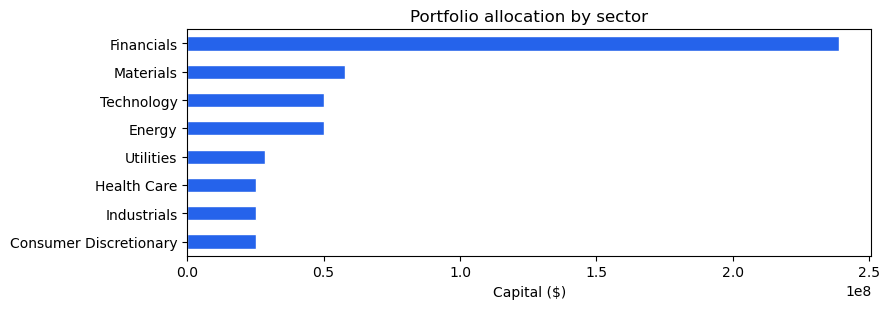

In [9]:
# =============================================================================
# 4. PORTFOLIO ANALYTICS  --  weighted metrics + allocation
# =============================================================================
fixed_df = pipeline["fixed"].set_index("CUSIP")
sel = r["sel"]
_w = r["h"][sel] / r["h"][sel].sum()

analytics = pd.DataFrame({
    "Metric": ["Bonds selected (h>$1)", "Wtd avg book yield (%)", "Wtd avg coupon yield (%)",
               "Wtd avg amortization (bps)", "Wtd avg OAS spread (bps)", "Wtd avg bond duration (yrs)",
               "Wtd avg RBC factor (%)", "Effective duration incl swap (yrs)",
               "Statutory earnings / req. capital"],
    "Value": [int(sel.sum()),
              f"{r['w_yield']*100:.2f}",
              f"{(coupon_inc[sel]*_w).sum()*100:.2f}",
              f"{(amort_inc[sel]*_w).sum()*1e4:+.1f}",
              f"{r['w_spread']*1e4:.1f}",
              f"{r['w_dur']:.4f}",
              f"{r['w_theta']*100:.3f}",
              f"{r['D_eff']:.4f}",
              f"{r['NII']/(RBC_bar*r['RBC']):.4f}"],
})
display(analytics)

alloc = pd.DataFrame({
    "CUSIP": CUSIPS,
    "Sector": [str(fixed_df.loc[c, "sector"]) for c in CUSIPS],
    "Rating": [str(fixed_df.loc[c, "rating_sp"]).strip() for c in CUSIPS],
    "h_opt ($)": r["h"], "Book yield (%)": book_yield*100, "Duration (yr)": durs,
    "OAS (bps)": spread*1e4, "RBC f_i (%)": theta*100,
})
alloc = alloc[alloc["h_opt ($)"] > 1.0].sort_values("h_opt ($)", ascending=False).reset_index(drop=True)
print(f"Non-zero allocations: {len(alloc)} / {N} bonds")
display(alloc)

# sector allocation chart
sec = {}
for i, c in enumerate(CUSIPS):
    s = str(fixed_df.loc[c, "sector"]); sec[s] = sec.get(s, 0.0) + r["h"][i]
ss = pd.Series(sec); ss = ss[ss > 0].sort_values()
fig, ax = plt.subplots(figsize=(9, max(3, len(ss)*0.4)))
ss.plot(kind="barh", ax=ax, color="#2563eb", edgecolor="white")
ax.set_title("Portfolio allocation by sector"); ax.set_xlabel("Capital ($)")
plt.tight_layout(); plt.show()

---
## Section 5 — Surplus-CVaR calibration sweep

How the matched book responds as the **surplus** risk budget `phi_cvar` tightens/loosens. Because the rate tail is netted, the surplus tail floor is small (pure credit) — the sweep shows where it binds and what it costs in NII/SAP.

SURPLUS-CVaR SWEEP  (D_eff pinned to D_FABN throughout)
phi_cvar  budget $M   feas  NII $M  SAP $M  D_eff  swap $M  surplus tail $M  nsel
   0.20%        1.0 INFEAS     NaN     NaN    NaN      NaN              NaN   NaN
   0.30%        1.5 INFEAS     NaN     NaN    NaN      NaN              NaN   NaN
   0.40%        2.0     ok   15.48  12.478   2.49      0.0             1.63  31.0
   0.50%        2.5     ok   15.48  12.478   2.49      0.0             1.63  31.0
   0.60%        3.0     ok   15.48  12.478   2.49      0.0             1.63  31.0
   0.80%        4.0     ok   15.48  12.478   2.49      0.0             1.63  31.0
   1.00%        5.0     ok   15.48  12.478   2.49      0.0             1.63  31.0
   1.50%        7.5     ok   15.48  12.478   2.49      0.0             1.63  31.0
   2.00%       10.0     ok   15.48  12.478   2.49      0.0             1.63  31.0


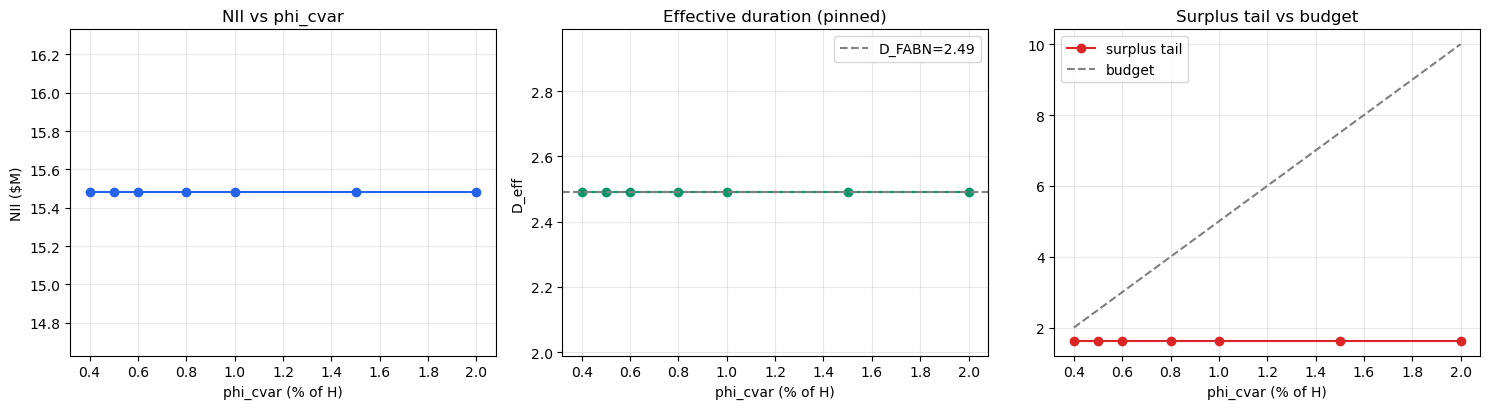

In [10]:
# =============================================================================
# 5. SURPLUS-CVaR SWEEP
# =============================================================================
phis = [0.002,0.003,0.004,0.005,0.006,0.008,0.010,0.015,0.020]
rec = []
for p in phis:
    rr = solve_model(phi_cvar=p)
    if rr["ok"]:
        rec.append(dict(phi=p, NII=rr["NII"], SAP=rr["SAP"], D_eff=rr["D_eff"],
                        swap=rr["swap_notional"], stail=rr["surplus_tail"], nsel=rr["nsel"]))
    else:
        rec.append(dict(phi=p, NII=np.nan, SAP=np.nan, D_eff=np.nan, swap=np.nan, stail=np.nan, nsel=np.nan))
sweep = pd.DataFrame(rec)
disp = pd.DataFrame({
    "phi_cvar": sweep.phi.map(lambda x: f"{x*100:.2f}%"), "budget $M": (sweep.phi*H/1e6).round(1),
    "feas": np.where(sweep.SAP.notna(), "ok", "INFEAS"),
    "NII $M": (sweep.NII/1e6).round(3), "SAP $M": (sweep.SAP/1e6).round(3),
    "D_eff": sweep.D_eff.round(3), "swap $M": (sweep.swap/1e6).round(1),
    "surplus tail $M": (sweep.stail/1e6).round(2), "nsel": sweep.nsel})
print("SURPLUS-CVaR SWEEP  (D_eff pinned to D_FABN throughout)")
print(disp.to_string(index=False))

_f = sweep[sweep.SAP.notna()]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].plot(_f.phi*100, _f.NII/1e6, "o-", color="#2563eb"); ax[0].set_title("NII vs phi_cvar"); ax[0].set_ylabel("NII ($M)")
ax[1].plot(_f.phi*100, _f.D_eff, "o-", color="#059669"); ax[1].axhline(D_FABN, ls="--", c="grey", label=f"D_FABN={D_FABN:.2f}")
ax[1].set_title("Effective duration (pinned)"); ax[1].set_ylabel("D_eff"); ax[1].legend(); ax[1].set_ylim(D_FABN-0.5, D_FABN+0.5)
ax[2].plot(_f.phi*100, _f.stail/1e6, "o-", color="#dc2626", label="surplus tail")
ax[2].plot(_f.phi*100, _f.phi*H/1e6, "--", color="grey", label="budget"); ax[2].set_title("Surplus tail vs budget"); ax[2].legend()
for a in ax: a.set_xlabel("phi_cvar (% of H)"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Section 6 — Does the swap earn its keep?  *(capacity demonstration)*

On the full universe the swap sits at ~$0 because the credit-optimal book **already** matches `D_FABN`. To see the swap do its job, restrict the universe to **longer bonds** (mimicking a mandate or an opportunity set that pushes the book off-target) and require the exact duration match. The swap becomes the *only* way to stay feasible.

In [11]:
# =============================================================================
# 6. SWAP CAPACITY DEMONSTRATION
# =============================================================================
def demo(min_dur, use_swaps, tenors=None, cap=swap_cap_pct):
    mask = durs >= min_dur
    return solve_model(phi_cvar=0.02, use_swaps=use_swaps, dur_match=True,
                       elig=mask, swap_tenors=tenors, swap_cap=cap), int(mask.sum())

print("Full universe (base):")
b = res
print(f"   swap=${b['swap_notional']/1e6:5.1f}M  D_bonds={b['D_bonds']:.3f}  D_eff={b['D_eff']:.3f}  SAP=${b['SAP']/1e6:.3f}M\\n")

print("Restrict to LONG bonds, standard [1,2,3]yr swaps (cap 20%):")
for md_ in [2.5, 2.7, 3.0]:
    ron, ne = demo(md_, True); roff, _ = demo(md_, False)
    so = "INFEASIBLE" if not ron["ok"] else f"swap=${ron['swap_notional']/1e6:5.1f}M D_bonds={ron['D_bonds']:.3f} D_eff={ron['D_eff']:.3f} SAP=${ron['SAP']/1e6:.2f}M"
    sf = "INFEASIBLE" if not roff["ok"] else f"SAP=${roff['SAP']/1e6:.2f}M"
    print(f"   dur>={md_}yr ({ne:3d} bonds)  swaps ON: {so:56s} | swaps OFF: {sf}")

print("\\nSame long universe, LONGER [3,5,7]yr swaps (cap 30%) -- full duration transformation:")
for md_ in [3.0, 3.5]:
    ron, ne = demo(md_, True, tenors=[3.,5.,7.], cap=0.30)
    if ron["ok"]:
        print(f"   dur>={md_}yr ({ne:3d} bonds): D_bonds={ron['D_bonds']:.3f} D_swap={ron['D_swap']:+.3f} "
              f"D_eff={ron['D_eff']:.3f}  swap=${ron['swap_notional']/1e6:.0f}M  NII=${ron['NII']/1e6:.3f}M  SAP=${ron['SAP']/1e6:.3f}M")
    else:
        print(f"   dur>={md_}yr ({ne:3d} bonds): INFEASIBLE (need even longer tenor / more notional)")

print("\\nReadings:")
print(" - Full universe: swap ~ $0  (book already at D_FABN -> swap correctly rests).")
print(" - Forced long + short swaps: swap MAXES OUT and matches D_eff to D_FABN; swaps-OFF is INFEASIBLE.")
print(" - Forced long + [3,5,7]yr swaps: bonds run ~4yr, swap pulls D_eff to EXACTLY D_FABN. Mechanism works.")
print(" - NB SAP FALLS as you force longer -> confirms there is no term premium at this date;")
print("   the swap makes long bonds *safe*, but long bonds are not *worth* holding here.")

Full universe (base):
   swap=$  0.0M  D_bonds=2.490  D_eff=2.490  SAP=$12.478M\n
Restrict to LONG bonds, standard [1,2,3]yr swaps (cap 20%):


   dur>=2.5yr (173 bonds)  swaps ON: swap=$100.0M D_bonds=3.035 D_eff=2.490 SAP=$11.50M       | swaps OFF: INFEASIBLE


   dur>=2.7yr (156 bonds)  swaps ON: swap=$100.0M D_bonds=3.035 D_eff=2.490 SAP=$10.76M       | swaps OFF: INFEASIBLE


   dur>=3.0yr (131 bonds)  swaps ON: INFEASIBLE                                               | swaps OFF: INFEASIBLE
\nSame long universe, LONGER [3,5,7]yr swaps (cap 30%) -- full duration transformation:
   dur>=3.0yr (131 bonds): D_bonds=3.977 D_swap=-1.487 D_eff=2.490  swap=$127M  NII=$14.149M  SAP=$11.183M


   dur>=3.5yr ( 87 bonds): D_bonds=4.246 D_swap=-1.757 D_eff=2.490  swap=$150M  NII=$13.217M  SAP=$10.539M
\nReadings:
 - Full universe: swap ~ $0  (book already at D_FABN -> swap correctly rests).
 - Forced long + short swaps: swap MAXES OUT and matches D_eff to D_FABN; swaps-OFF is INFEASIBLE.
 - Forced long + [3,5,7]yr swaps: bonds run ~4yr, swap pulls D_eff to EXACTLY D_FABN. Mechanism works.
 - NB SAP FALLS as you force longer -> confirms there is no term premium at this date;
   the swap makes long bonds *safe*, but long bonds are not *worth* holding here.


---
## Section 7 — Read-out & comparison

**What changed vs the asset-CVaR notebook.** Netting the FABN liability into the tail measure turns the risk metric from *"how much would I lose dumping assets after a rate spike"* into *"how much surplus (assets − liability) would I lose"*. Because a duration-matched book has its asset and liability rate moves cancel, matching is now the **cheap, feasible** solution instead of the infeasible one — and the residual tail the CVaR governs is genuine **credit/spread** risk.

**On the swap.** With the hard match `D(bonds)+D(swap)=D_FABN`, the swap is available to correct any duration gap. At `2025-01-15` the credit-optimal book already sits at the liability duration, so the swap rests at ~$0 — that is the *right* answer, not a failure. Section 6 shows it activates immediately and matches duration exactly the moment the bond book is pushed off-target.

**The honest caveat (root cause that no risk model can fix).** Book yield is nearly flat in duration at this date (~+0.05%/yr), so forcing the book longer *lowers* SAP. The surplus-CVaR fixes the *risk-model* obstacle to your intended trade; it does not manufacture a term premium. The "hold longer bonds for extra spread, hedge back to the note" thesis only pays when the yield-vs-duration slope is materially positive — verify that on your dates/universe before leaning on it. Two practical levers that make the overlay usable when it *is* worth going long: **longer swap tenors (5–10yr)** and a **higher notional cap** (the 1–3yr / 20% menu offsets only ~0.5yr).

In [12]:
# side-by-side: current asset-CVaR (band off) vs this surplus-CVaR + match
_asset = solve_model(phi_cvar=phi_cvar, dur_match=False, surplus=False)   # approximates the current notebook
cmp = pd.DataFrame({
    "": ["D bonds (yr)","D effective (yr)","Swap notional ($M)","NII ($M)","SAP ($M)",
         "Asset tail ($M)","Surplus tail ($M)","Earn / req. capital"],
    "Asset-CVaR (current)": [f"{_asset['D_bonds']:.3f}", f"{_asset['D_eff']:.3f}", f"{_asset['swap_notional']/1e6:.1f}",
        f"{_asset['NII']/1e6:.3f}", f"{_asset['SAP']/1e6:.3f}", f"{_asset['asset_tail']/1e6:.2f}",
        f"{_asset['surplus_tail']/1e6:.2f}", f"{_asset['NII']/(RBC_bar*_asset['RBC']):.3f}"],
    "Surplus-CVaR + match": [f"{r['D_bonds']:.3f}", f"{r['D_eff']:.3f}", f"{r['swap_notional']/1e6:.1f}",
        f"{r['NII']/1e6:.3f}", f"{r['SAP']/1e6:.3f}", f"{r['asset_tail']/1e6:.2f}",
        f"{r['surplus_tail']/1e6:.2f}", f"{r['NII']/(RBC_bar*r['RBC']):.3f}"],
})
print("COMPARISON @ phi_cvar = %.2f%%" % (phi_cvar*100))
display(cmp)

COMPARISON @ phi_cvar = 1.00%


,,Asset-CVaR (current),Surplus-CVaR + match
0,D bonds (yr),2.488,2.490
1,D effective (yr),2.008,2.490
2,Swap notional ($M),88.0,0.0
3,NII ($M),15.482,15.480
4,SAP ($M),12.398,12.478
5,Asset tail ($M),4.98,6.21
6,Surplus tail ($M),2.59,1.63
7,Earn / req. capital,0.947,0.948
